In [1]:
import torch
import torch.nn as nn
import json
from torch.utils.data import DataLoader
import pandas as pd

from src.classifier import Classifier
from src.trainer import Trainer
from src.datasets_classes import MultiDomainDataset, multidomain_collate_fn
from src.utils.evaluation import compute_classification_reports, save_confusion_matrices, build_summary_table, plot_domain_metric_bar, save_combined_confusion_matrix
from src.config import MODEL_OUTPUT_DIM

c:\Users\alice\master_thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



AVES2


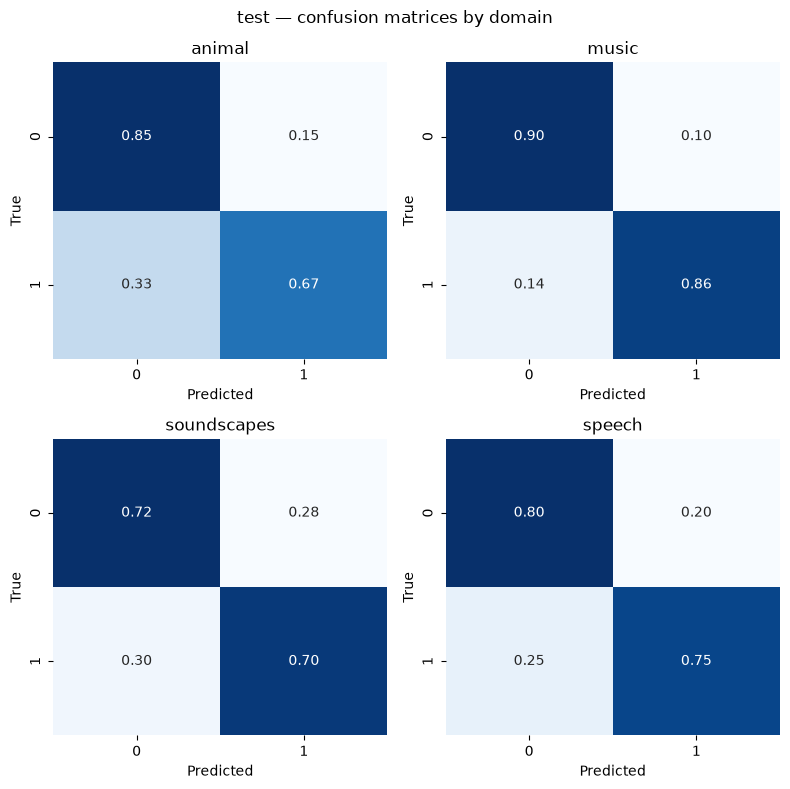


CLAP


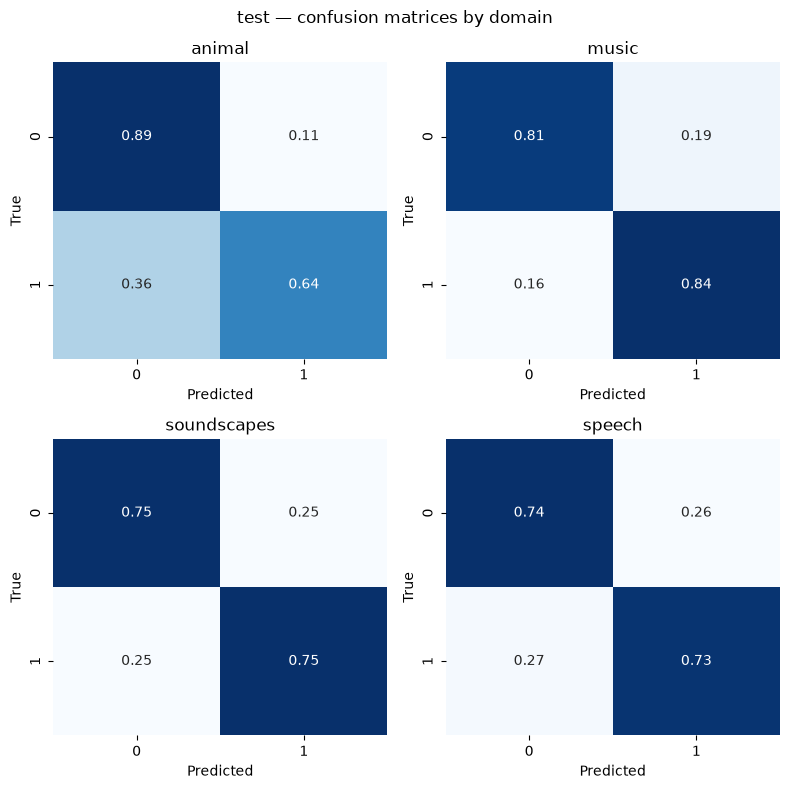


E2V


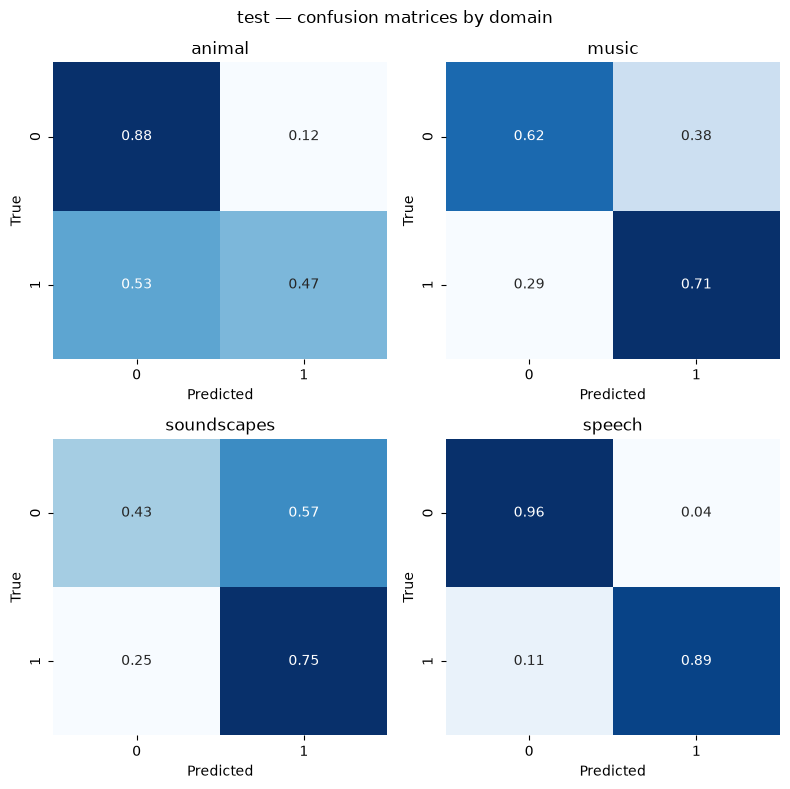


MERT


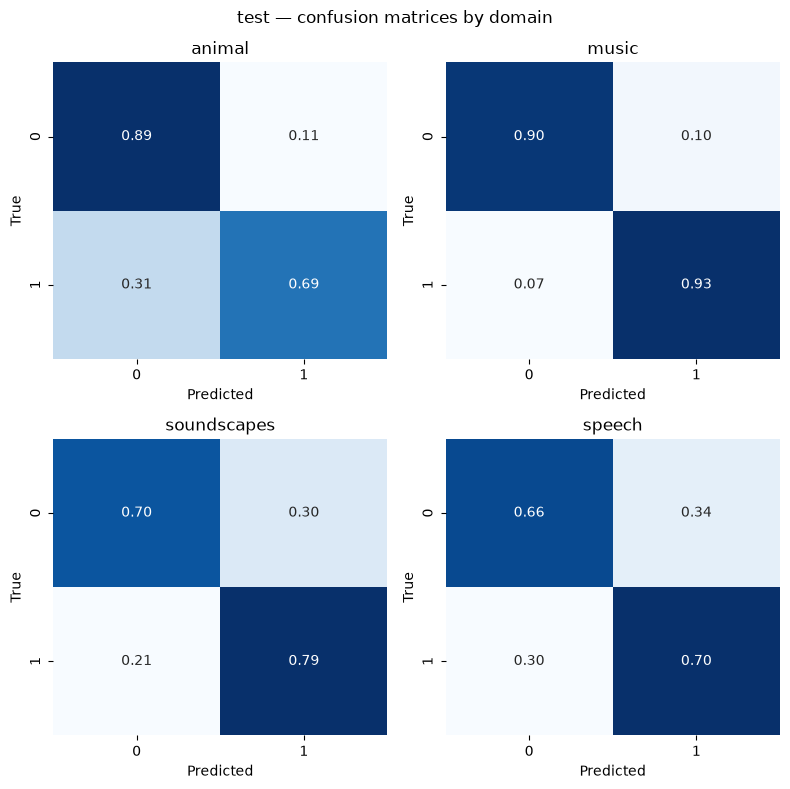

In [2]:
MODELS = ["aves2", "clap", "e2v", "mert"]

all_reports = {}
all_trainers = {}

for model_name in MODELS:

    print(f"\n{model_name.upper()}")

    test_dataset = MultiDomainDataset("outputs/embeddings/test", model_filter=model_name)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=multidomain_collate_fn)

    checkpoint = torch.load(f"outputs/models/{model_name}_best_model.pt", map_location=torch.device("cpu"))


    projectors = nn.ModuleDict({domain: nn.Identity() for domain in test_dataset.domain_data})
    classifier = Classifier(shared_dim=checkpoint["shared_dim"], hidden_dim = checkpoint["hidden_dim"], dropout=checkpoint["dropout"])

    projectors.load_state_dict(checkpoint["projectors_state_dict"])
    classifier.load_state_dict(checkpoint["classifier_state_dict"])

    trainer = Trainer(projectors, classifier, shared_dim=checkpoint["shared_dim"])

    reports = compute_classification_reports(trainer, [("test", test_loader)])
    all_reports[model_name] = reports

    all_trainers[model_name] = trainer

    with open(f"outputs/tables/{model_name}_test_classification_report.json", "w") as f:
        json.dump(reports, f, indent=2)

    save_combined_confusion_matrix(trainer, test_loader, split_name="test", output_dir=f"plots/confusion_matrices/{model_name}")

In [3]:
rows = []
for model_name, report in all_reports.items():
    for domain, domain_report in report["test"]["domains"].items():
        rows.append({
            "model": model_name,
            "domain": domain,
            "balanced_accuracy": domain_report["balanced_accuracy"],
        })

summary_df = pd.DataFrame(rows)
pivot = summary_df.pivot(index="domain", columns="model", values="balanced_accuracy")
print("Balanced accuracy values for domain and model on test set")
display(pivot)

Balanced accuracy values for domain and model on test set


model,aves2,clap,e2v,mert
domain,,,,
animal,0.763021,0.764062,0.673958,0.787500
music,0.880952,0.824405,0.666667,0.916667
soundscapes,0.713115,0.754098,0.590164,0.745902
speech,0.776180,0.736009,0.927162,0.679107


AVES2


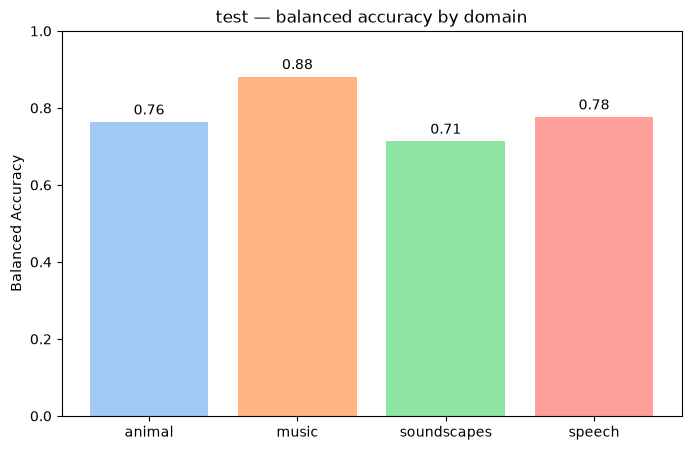

CLAP


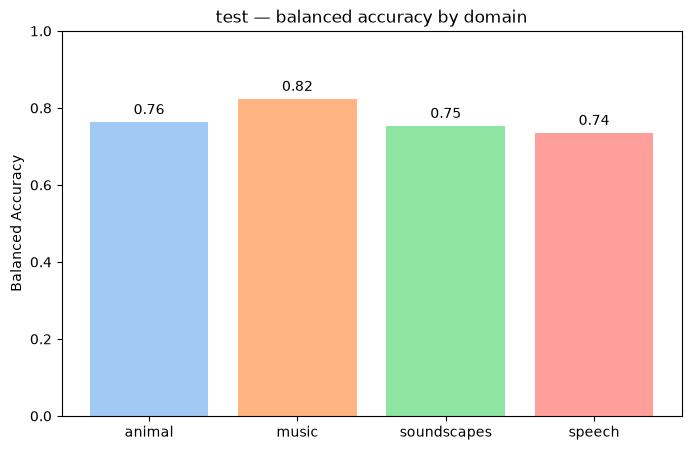

E2V


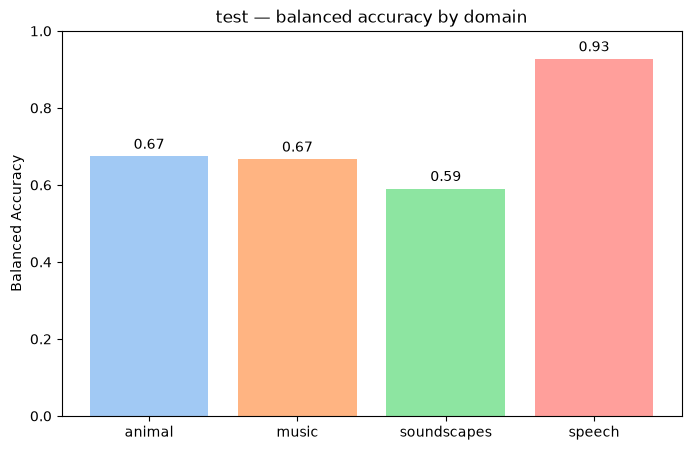

MERT


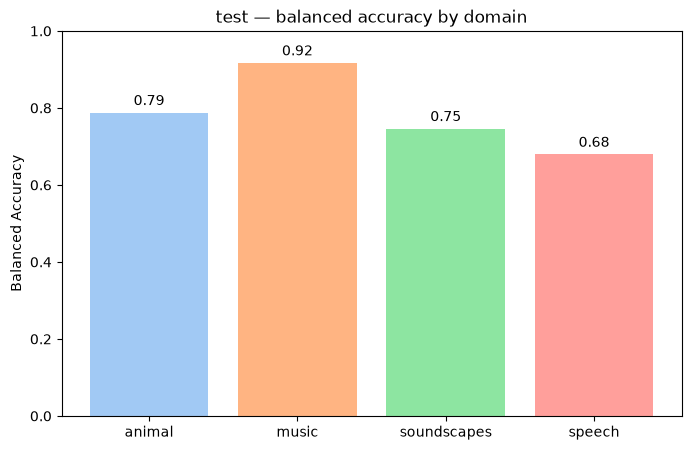

In [4]:
for model_name, report in all_reports.items():
    print(f"{model_name.upper()}")
    plot_domain_metric_bar(report, split_name="test", metric="balanced_accuracy", filename=f"plots/{model_name}_test_summary_bar.png")